# PyTorch FNN Fault Diagnosis with DAQ Data & Batch Learning

이 노트북은 `data_200_200_200.csv`를 불러와 다음 작업을 수행합니다.

- 입력: a상 전류 200개 + b상 전류 200개 + c상 전류 200개
- 출력: 마지막 열의 Fault ID
- Train/Test 데이터는 동일하게 사용
- 표준화
- DataLoader 기반 미니배치 FNN 고장진단 모델 학습
- Epoch별 Train/Test loss 저장
- 클래스별 3상 전류 및 Fault ID 그림 저장
- Confusion matrix 저장
- 추정 결과 CSV 저장
- 학습 모델 및 scaler 정보 저장


In [15]:
# 1. 라이브러리 및 Google Drive 연결

import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from pathlib import Path
import subprocess
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
REPO_ROOT = Path("/content/BasicExample_Diagnosis_copy") if IN_COLAB else Path(r"C:\Users\HP\Documents\Github\BasicExample_Diagnosis")
if IN_COLAB and not REPO_ROOT.exists(): subprocess.run(["git", "clone", "-q", "https://github.com/Jaehoon-Shim/BasicExample_Diagnosis.git", str(REPO_ROOT)], check=True)
if not REPO_ROOT.exists(): raise FileNotFoundError(f"저장소 폴더를 찾을 수 없습니다: {REPO_ROOT}")
RESULT_DIR = REPO_ROOT / "results_wBatchLearning"
CSV_PATH = REPO_ROOT / "data" / "data_200_200_200.csv"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print(REPO_ROOT, RESULT_DIR, CSV_PATH, sep="\n")

C:\Users\HP\Documents\Github\BasicExample_Diagnosis
C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning
C:\Users\HP\Documents\Github\BasicExample_Diagnosis\data\data_200_200_200.csv


In [16]:
# 2. 설정

SEED = 42
EPOCHS = 800
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
PRINT_INTERVAL = 1
SAMPLES_PER_PHASE = 200
INPUT_SIZE = SAMPLES_PER_PHASE * 3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device    :', DEVICE)
print('Batch Size:', BATCH_SIZE)
print('CSV Path  :', CSV_PATH)
print('Result Dir:', RESULT_DIR)
print('CSV Exists:', os.path.exists(CSV_PATH))


Device    : cpu
Batch Size: 32
CSV Path  : C:\Users\HP\Documents\Github\BasicExample_Diagnosis\data\data_200_200_200.csv
Result Dir: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning
CSV Exists: True


In [17]:
# 3. CSV 로드 및 전처리

# 헤더가 없는 CSV 파일
df = pd.read_csv(CSV_PATH, header=None)

# 불필요한 인덱스 열 제거
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]

# 모든 값을 숫자로 변환하고 결측값 제거
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna().reset_index(drop=True)

# 입력 600열 + 마지막 Fault ID 1열 확인
if df.shape[1] != INPUT_SIZE + 1:
    raise ValueError(
        f'CSV는 입력 {INPUT_SIZE}열과 Fault ID 1열로 구성되어야 합니다. '
        f'현재 열 개수: {df.shape[1]}'
    )

feature_columns = (
    [f'Ia_{i + 1}' for i in range(SAMPLES_PER_PHASE)]
    + [f'Ib_{i + 1}' for i in range(SAMPLES_PER_PHASE)]
    + [f'Ic_{i + 1}' for i in range(SAMPLES_PER_PHASE)]
)

df.columns = feature_columns + ['Fault_ID']
df['Fault_ID'] = df['Fault_ID'].astype(int)

class_ids = np.sort(df['Fault_ID'].unique())
NUM_CLASSES = len(class_ids)

if not np.array_equal(class_ids, np.arange(NUM_CLASSES)):
    raise ValueError(
        f'Fault ID는 0부터 연속된 정수여야 합니다. 현재 ID: {class_ids}'
    )

print('Data shape:', df.shape)
print('Fault ID별 데이터 개수:')
print(df['Fault_ID'].value_counts().sort_index())
display(df.head())
display(df.describe())


Data shape: (210, 601)
Fault ID별 데이터 개수:
Fault_ID
0    30
1    30
2    30
3    30
4    30
5    30
6    30
Name: count, dtype: int64


,Ia_1,Ia_2,Ia_3,Ia_4,Ia_5,Ia_6,Ia_7,Ia_8,Ia_9,Ia_10,...,Ic_192,Ic_193,Ic_194,Ic_195,Ic_196,Ic_197,Ic_198,Ic_199,Ic_200,Fault_ID
0,-0.2103,0.0781,0.3305,0.6022,0.8847,1.1297,1.3671,1.6296,1.9235,2.2170,...,-3.9785,-3.9942,-4.0034,-3.9920,-3.9303,-3.8325,-3.6686,-3.4787,-3.3170,0
1,-0.1639,0.1726,0.4938,0.7526,0.9792,1.2459,1.5277,1.8187,2.1508,2.4715,...,-3.8018,-3.6696,-3.4923,-3.3132,-3.1802,-3.0565,-2.9144,-2.7818,-2.5722,0
2,-0.5098,-0.2344,0.0087,0.2625,0.5478,0.8406,1.1317,1.4201,1.7068,2.0016,...,-3.4594,-3.7936,-4.1480,-4.4765,-4.7604,-5.0258,-5.2866,-5.5495,-5.8118,0
3,-0.3949,-0.3350,-0.2721,-0.2059,-0.1368,-0.0666,0.0003,0.0646,0.1302,0.1989,...,-3.2667,-3.2165,-3.1604,-3.1021,-3.0479,-2.9994,-2.9536,-2.9070,-2.8567,0
4,-0.1042,0.0854,0.2103,0.3871,0.6596,0.9206,1.1265,1.3535,1.6359,1.9207,...,2.3986,2.4072,2.3914,2.4151,2.4954,2.5128,2.4812,2.4246,2.3037,0


,Ia_1,Ia_2,Ia_3,Ia_4,Ia_5,Ia_6,Ia_7,Ia_8,Ia_9,Ia_10,...,Ic_192,Ic_193,Ic_194,Ic_195,Ic_196,Ic_197,Ic_198,Ic_199,Ic_200,Fault_ID
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,...,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,-0.414095,-0.043090,0.293856,0.621409,0.950821,1.278216,1.606365,1.934140,2.250156,2.547015,...,-1.989147,-1.926170,-1.858949,-1.789445,-1.716083,-1.643358,-1.574445,-1.508410,-1.449305,3.000000
std,2.008466,1.991598,2.029131,2.120088,2.253141,2.416387,2.601911,2.801850,2.998590,3.177357,...,4.591381,4.505202,4.451374,4.435694,4.458031,4.503999,4.559776,4.634866,4.723878,2.004779
min,-5.999400,-5.759400,-5.513900,-5.266700,-5.015000,-4.756200,-4.493100,-4.228200,-3.964700,-3.702100,...,-14.688700,-14.660100,-14.618800,-14.569800,-14.514200,-14.444500,-14.357400,-14.419600,-14.463900,0.000000
25%,-1.117825,-0.605750,-0.389975,-0.257275,-0.187675,-0.155200,-0.114350,-0.067575,-0.054850,-0.034975,...,-4.330850,-4.454275,-4.443325,-4.373450,-4.145600,-4.173075,-4.131325,-4.028325,-4.007850,1.000000
50%,-0.494950,-0.177150,0.012100,0.198500,0.377300,0.675550,0.958800,1.242550,1.539600,1.787450,...,-1.742650,-1.680050,-1.583900,-1.475500,-1.091800,-1.008750,-0.819750,-0.562050,-0.530700,3.000000
75%,0.032650,0.214400,0.612800,1.057925,1.570225,2.138675,2.756125,3.328975,3.902225,4.425025,...,0.554950,0.387775,0.442825,0.465025,0.382325,0.475950,0.440850,0.397100,0.822500,5.000000
max,6.521100,6.918300,7.799200,8.657900,9.486700,10.263500,11.014900,11.704600,12.325300,12.825000,...,9.564900,8.967500,8.316300,8.093500,9.457400,10.563900,11.177100,12.034300,12.832500,6.000000


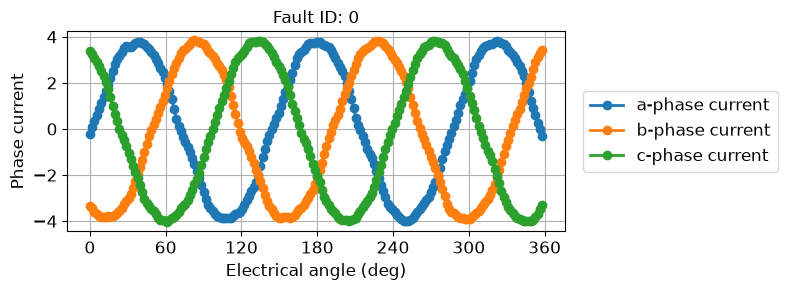

Saved: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fault_id_0_phase_current.jpg


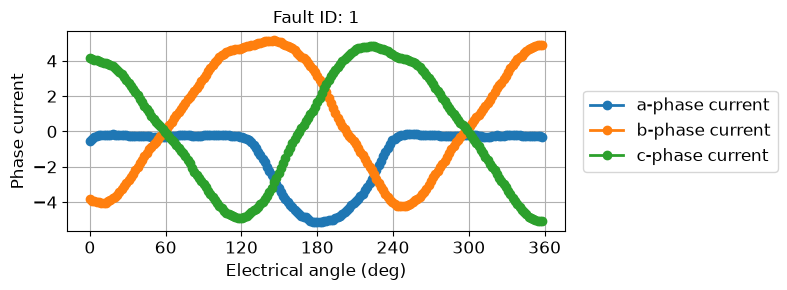

Saved: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fault_id_1_phase_current.jpg


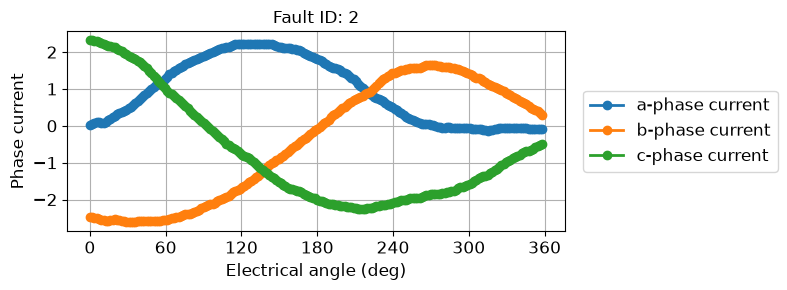

Saved: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fault_id_2_phase_current.jpg


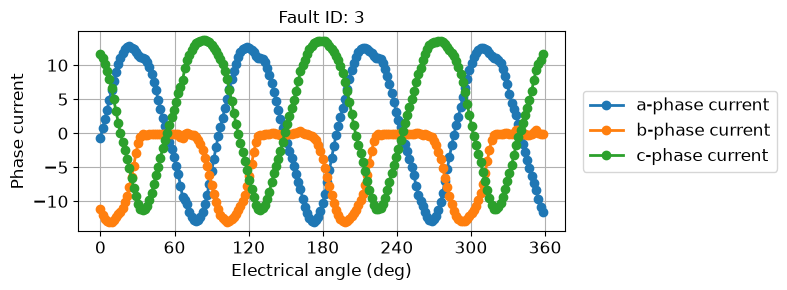

Saved: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fault_id_3_phase_current.jpg


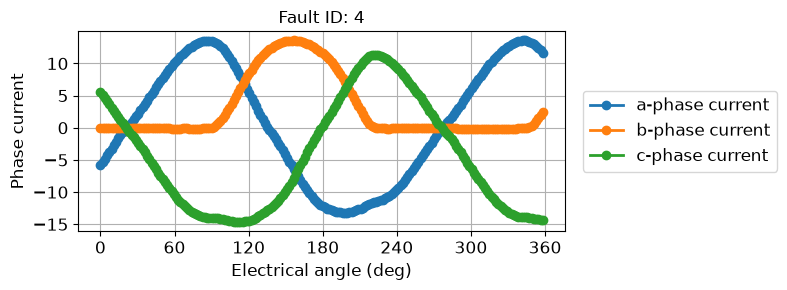

Saved: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fault_id_4_phase_current.jpg


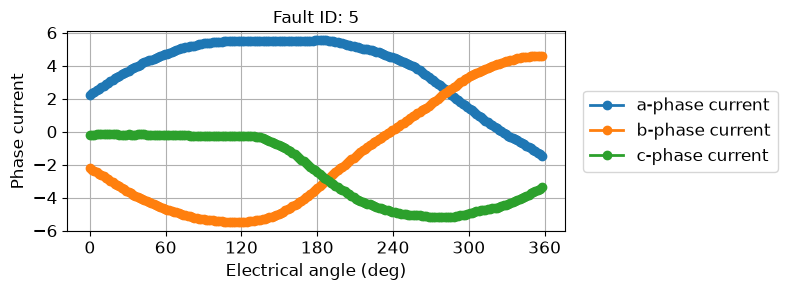

Saved: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fault_id_5_phase_current.jpg


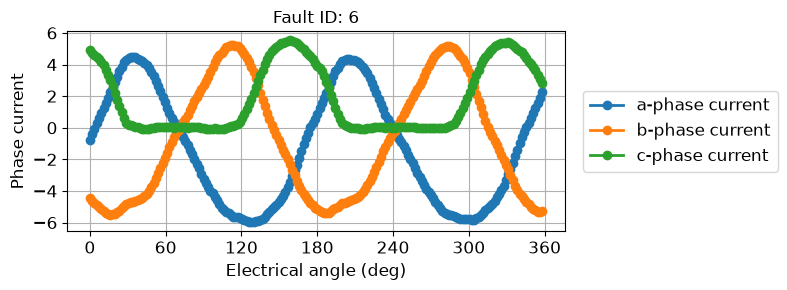

Saved: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fault_id_6_phase_current.jpg


In [18]:
# 3-1. 클래스별 3상 전류 플롯

sample_angles = np.linspace(0, 360, SAMPLES_PER_PHASE, endpoint=False)

for fault_id in class_ids:

    # 각 클래스에서 대표 데이터 하나 선택
    sample = (
        df[df['Fault_ID'] == fault_id]
        .iloc[0, :-1]
        .to_numpy(dtype=np.float32)
    )

    # 전체 600열을 상별 200개씩 3등분
    a_phase_current = sample[:SAMPLES_PER_PHASE]
    b_phase_current = sample[SAMPLES_PER_PHASE:2 * SAMPLES_PER_PHASE]
    c_phase_current = sample[2 * SAMPLES_PER_PHASE:INPUT_SIZE]

    plt.figure(figsize=(8, 3))

    plt.plot(
        sample_angles,
        a_phase_current,
        marker='o',
        linewidth=2,
        label='a-phase current'
    )

    plt.plot(
        sample_angles,
        b_phase_current,
        marker='o',
        linewidth=2,
        label='b-phase current'
    )

    plt.plot(
        sample_angles,
        c_phase_current,
        marker='o',
        linewidth=2,
        label='c-phase current'
    )

    plt.xlabel('Electrical angle (deg)', fontsize=12)
    plt.ylabel('Phase current', fontsize=12)
    plt.title(f'Fault ID: {fault_id}', fontsize=12)
    plt.xticks(np.arange(0, 361, 60), fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True)
    plt.legend(
        fontsize=12,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()

    original_data_path = os.path.join(
        RESULT_DIR,
        f'fault_id_{fault_id}_phase_current.jpg'
    )

    plt.savefig(original_data_path, dpi=300, bbox_inches='tight')
    plt.show()

    print('Saved:', original_data_path)


In [19]:
# 4. 입력/출력 구성 및 표준화

X = df.iloc[:, :-1].to_numpy(dtype=np.float32)
y = df.iloc[:, -1].to_numpy(dtype=np.int64)

# 요청에 따라 train/test 동일
X_train = X.copy()
y_train = y.copy()

X_test = X.copy()
y_test = y.copy()

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = x_scaler.transform(X_test).astype(np.float32)

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

data_generator = torch.Generator()
data_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=data_generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print('X_train:', X_train_tensor.shape)
print('y_train:', y_train_tensor.shape)
print('Train batches:', len(train_loader))
print('Test batches :', len(test_loader))


X_train: torch.Size([210, 600])
y_train: torch.Size([210])
Train batches: 7
Test batches : 7


In [20]:
# 5. FNN 모델 정의

class FNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(INPUT_SIZE, 2),
            nn.ReLU(),
            nn.Linear(2, 24),
            nn.ReLU(),
            nn.Linear(24, NUM_CLASSES)
        )

    def forward(self, x):
        return self.model(x)


model = FNNClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=100
)

print(model)


FNNClassifier(
  (model): Sequential(
    (0): Linear(in_features=600, out_features=2, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=7, bias=True)
  )
)


In [21]:
# 6. 모델 학습

train_loss_history = []
test_loss_history = []

best_test_loss = float('inf')
best_model_state = None

for epoch in range(1, EPOCHS + 1):

    # Mini-batch Train
    model.train()

    train_loss_sum = 0.0
    train_sample_count = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        optimizer.zero_grad()

        train_logits = model(batch_X)
        train_loss = criterion(train_logits, batch_y)

        train_loss.backward()
        optimizer.step()

        current_batch_size = batch_X.size(0)
        train_loss_sum += train_loss.item() * current_batch_size
        train_sample_count += current_batch_size

    train_loss_value = train_loss_sum / train_sample_count

    # Mini-batch Test
    model.eval()

    test_loss_sum = 0.0
    test_sample_count = 0

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            test_logits = model(batch_X)
            test_loss = criterion(test_logits, batch_y)

            current_batch_size = batch_X.size(0)
            test_loss_sum += test_loss.item() * current_batch_size
            test_sample_count += current_batch_size

    test_loss_value = test_loss_sum / test_sample_count

    train_loss_history.append(train_loss_value)
    test_loss_history.append(test_loss_value)

    scheduler.step(test_loss_value)

    if test_loss_value < best_test_loss:
        best_test_loss = test_loss_value
        best_model_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % PRINT_INTERVAL == 0:
        current_lr = optimizer.param_groups[0]['lr']

        print(
            f'Epoch {epoch:4d}/{EPOCHS} | '
            f'Train Loss: {train_loss_value:.8f} | '
            f'Test Loss: {test_loss_value:.8f} | '
            f'LR: {current_lr:.6f}'
        )

model.load_state_dict(best_model_state)

print()
print('Best Test Loss:', best_test_loss)


Epoch    1/800 | Train Loss: 1.96306920 | Test Loss: 1.93163104 | LR: 0.001000
Epoch    2/800 | Train Loss: 1.91637275 | Test Loss: 1.89172845 | LR: 0.001000
Epoch    3/800 | Train Loss: 1.87839040 | Test Loss: 1.84854299 | LR: 0.001000
Epoch    4/800 | Train Loss: 1.82335778 | Test Loss: 1.79043822 | LR: 0.001000
Epoch    5/800 | Train Loss: 1.76709634 | Test Loss: 1.72642347 | LR: 0.001000
Epoch    6/800 | Train Loss: 1.70272771 | Test Loss: 1.65873365 | LR: 0.001000
Epoch    7/800 | Train Loss: 1.62991683 | Test Loss: 1.59409921 | LR: 0.001000
Epoch    8/800 | Train Loss: 1.56958094 | Test Loss: 1.53545235 | LR: 0.001000
Epoch    9/800 | Train Loss: 1.51693829 | Test Loss: 1.48665250 | LR: 0.001000
Epoch   10/800 | Train Loss: 1.47073299 | Test Loss: 1.44620874 | LR: 0.001000
Epoch   11/800 | Train Loss: 1.43086074 | Test Loss: 1.40797432 | LR: 0.001000
Epoch   12/800 | Train Loss: 1.39409301 | Test Loss: 1.37197668 | LR: 0.001000
Epoch   13/800 | Train Loss: 1.36009337 | Test Loss:

In [22]:
# 7. Fault ID 추정

model.eval()

# Train/Test 추정
with torch.no_grad():
    train_logits = model(X_train_tensor.to(DEVICE))
    test_logits = model(X_test_tensor.to(DEVICE))

    y_train_pred = torch.argmax(
        train_logits,
        dim=1
    ).cpu().numpy()

    y_test_pred = torch.argmax(
        test_logits,
        dim=1
    ).cpu().numpy()

    y_test_probability = torch.softmax(
        test_logits,
        dim=1
    ).cpu().numpy()

print('Actual sample   :', y_test[:10])
print('Predicted sample:', y_test_pred[:10])


Actual sample   : [0 0 0 0 0 0 0 0 0 0]
Predicted sample: [0 0 0 2 0 2 0 0 0 0]


In [23]:
# 8. 성능지표

def evaluate(y_true, y_pred, name):
    accuracy = accuracy_score(y_true, y_pred)

    print(f'[{name}]')
    print(f'Accuracy: {accuracy:.8f}')
    print()

    print(
        classification_report(
            y_true,
            y_pred,
            labels=class_ids,
            target_names=[
                f'Fault ID {fault_id}'
                for fault_id in class_ids
            ],
            digits=4,
            zero_division=0
        )
    )

    return accuracy


train_accuracy = evaluate(
    y_train,
    y_train_pred,
    'Train'
)

test_accuracy = evaluate(
    y_test,
    y_test_pred,
    'Test'
)


[Train]
Accuracy: 0.86190476

              precision    recall  f1-score   support

  Fault ID 0     1.0000    0.7333    0.8462        30
  Fault ID 1     1.0000    1.0000    1.0000        30
  Fault ID 2     0.5172    1.0000    0.6818        30
  Fault ID 3     1.0000    0.5000    0.6667        30
  Fault ID 4     1.0000    1.0000    1.0000        30
  Fault ID 5     0.9615    0.8333    0.8929        30
  Fault ID 6     1.0000    0.9667    0.9831        30

    accuracy                         0.8619       210
   macro avg     0.9255    0.8619    0.8672       210
weighted avg     0.9255    0.8619    0.8672       210

[Test]
Accuracy: 0.86190476

              precision    recall  f1-score   support

  Fault ID 0     1.0000    0.7333    0.8462        30
  Fault ID 1     1.0000    1.0000    1.0000        30
  Fault ID 2     0.5172    1.0000    0.6818        30
  Fault ID 3     1.0000    0.5000    0.6667        30
  Fault ID 4     1.0000    1.0000    1.0000        30
  Fault ID 5     0.

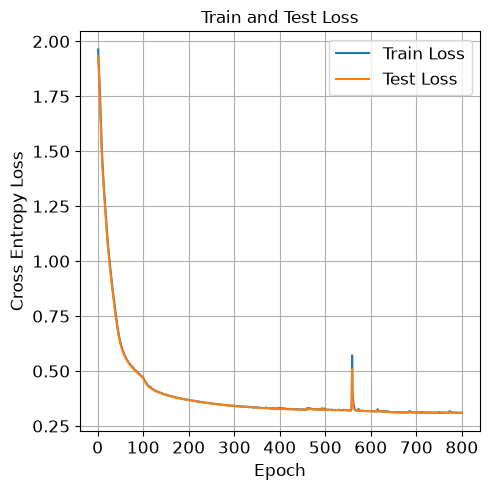

Saved: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\train_test_loss.jpg


In [24]:
# 9. Epoch별 Train/Test loss 저장

epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(5, 5))

plt.plot(epochs, train_loss_history, label='Train Loss')
plt.plot(epochs, test_loss_history, label='Test Loss')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross Entropy Loss', fontsize=12)
plt.title('Train and Test Loss', fontsize=12)
plt.grid(True)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()

loss_path = os.path.join(
    RESULT_DIR,
    'train_test_loss.jpg'
)

plt.savefig(loss_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', loss_path)


<Figure size 800x700 with 0 Axes>

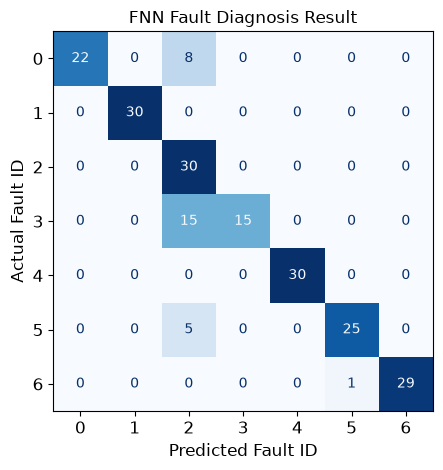

Saved: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fnn_fault_diagnosis_result.jpg


In [25]:
# 10. 전체 데이터 기준 고장진단 평가 결과

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=class_ids
)

plt.figure(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_ids
)

disp.plot(
    cmap='Blues',
    colorbar=False,
    values_format='d'
)

plt.xlabel('Predicted Fault ID', fontsize=12)
plt.ylabel('Actual Fault ID', fontsize=12)
plt.title('FNN Fault Diagnosis Result', fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

classification_path = os.path.join(
    RESULT_DIR,
    'fnn_fault_diagnosis_result.jpg'
)

plt.savefig(
    classification_path,
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print('Saved:', classification_path)


In [26]:
# ============================================================
# 결과 CSV, 학습 이력 CSV, PyTorch 모델(.pt) 저장
# ============================================================

# 추정 결과 CSV 저장
result_df = pd.DataFrame({
    'Actual_Fault_ID': y_test,
    'Predicted_Fault_ID': y_test_pred,
    'Confidence': y_test_probability.max(axis=1)
})

result_csv_path = os.path.join(
    RESULT_DIR,
    'fault_diagnosis_result.csv'
)

result_df.to_csv(result_csv_path, index=False)

# 학습 이력 CSV 저장
history_df = pd.DataFrame({
    'epoch': np.arange(1, EPOCHS + 1),
    'train_loss': train_loss_history,
    'test_loss': test_loss_history
})

history_csv_path = os.path.join(
    RESULT_DIR,
    'train_test_loss.csv'
)

history_df.to_csv(history_csv_path, index=False)

# 모델 가중치 저장
model_path = os.path.join(
    RESULT_DIR,
    'fnn_fault_model.pt'
)

model_cpu = model.to('cpu')
model_cpu.eval()

torch.save(
    model_cpu.state_dict(),
    model_path
)

if os.path.exists(model_path):
    print('모델 저장 성공')
    print('경로:', model_path)
    print('크기:', os.path.getsize(model_path), 'bytes')
else:
    print('모델 저장 실패')

print('x_mean :', x_scaler.mean_.astype(np.float32))
print('x_scale:', x_scaler.scale_.astype(np.float32))


모델 저장 성공
경로: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fnn_fault_model.pt
크기: 8885 bytes
x_mean : [-4.14094746e-01 -4.30904776e-02  2.93856174e-01  6.21408582e-01
  9.50821400e-01  1.27821624e+00  1.60636520e+00  1.93413949e+00
  2.25015569e+00  2.54701471e+00  2.81910229e+00  3.06465483e+00
  3.29051852e+00  3.49009132e+00  3.65254998e+00  3.78489137e+00
  3.89013910e+00  3.96284485e+00  4.00997448e+00  4.04031038e+00
  4.05152607e+00  4.03379726e+00  3.97867656e+00  3.88724613e+00
  3.76426482e+00  3.61787152e+00  3.46214342e+00  3.31418514e+00
  3.17755055e+00  3.04002810e+00  2.89111996e+00  2.72888470e+00
  2.55413342e+00  2.36839771e+00  2.17770243e+00  1.98825192e+00
  1.80420721e+00  1.63236189e+00  1.47677910e+00  1.32991481e+00
  1.19339097e+00  1.07859433e+00  9.81630921e-01  8.90700936e-01
  8.04195702e-01  7.21675694e-01  6.43965244e-01  5.80813348e-01
  5.33581913e-01  4.98924762e-01  4.82016206e-01  4.79523838e-01
  4.80548084e-01  4.8129

# 11. 학습 모델을 PT로 저장하고 EXE 제작 파일 준비

아래 셀들은 순서대로 실행합니다.

1. 모델 가중치와 입력 표준화 정보를 `fnn_fault_checkpoint.pt` 하나에 저장합니다.
2. 저장한 PT를 다시 로드하여 Colab에서 추론 결과가 같은지 검증합니다.
3. 이후 GUI 또는 임베디드 배포 코드에서 동일한 전처리와 모델을 사용할 수 있습니다.

> Google Colab은 Linux이므로 Windows EXE 자체는 Windows PC에서 빌드해야 합니다.


In [27]:
# 11-1. 체크포인트 PT 저장 및 다운로드

if IN_COLAB:
    from google.colab import files

model_cpu = model.to('cpu')
model_cpu.eval()

checkpoint = {
    'model_state_dict': model_cpu.state_dict(),
    'architecture': [INPUT_SIZE, 24, 24, NUM_CLASSES],
    'x_mean': x_scaler.mean_.astype(np.float32),
    'x_scale': x_scaler.scale_.astype(np.float32),
    'feature_names': feature_columns,
    'class_ids': class_ids.astype(np.int64),
    'input_name': 'a, b, c phase currents',
    'output_name': 'Fault ID'
}

PT_PATH = os.path.join(
    RESULT_DIR,
    'fnn_fault_checkpoint.pt'
)

torch.save(checkpoint, PT_PATH)

print('PT 저장 완료:', PT_PATH)
print('파일 크기:', os.path.getsize(PT_PATH), 'bytes')
if IN_COLAB:
    files.download(PT_PATH)


PT 저장 완료: C:\Users\HP\Documents\Github\BasicExample_Diagnosis\results_wBatchLearning\fnn_fault_checkpoint.pt
파일 크기: 25585 bytes


In [28]:
# 11-2. 저장된 PT 재로드 및 추론 검증

class LoadedFNNClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(INPUT_SIZE, 2), nn.ReLU(),
            nn.Linear(2, 24), nn.ReLU(),
            nn.Linear(24, num_classes)
        )

    def forward(self, x):
        return self.model(x)


loaded_checkpoint = torch.load(
    PT_PATH,
    map_location='cpu',
    weights_only=False
)

loaded_model = LoadedFNNClassifier(
    len(loaded_checkpoint['class_ids'])
)

loaded_model.load_state_dict(
    loaded_checkpoint['model_state_dict']
)
loaded_model.eval()


def predict_from_pt(x_values):
    x_values = np.asarray(
        x_values,
        dtype=np.float32
    ).reshape(1, -1)

    if x_values.shape[1] != INPUT_SIZE:
        raise ValueError(f'입력 데이터는 {INPUT_SIZE}개여야 합니다.')

    x_scaled = (
        x_values - loaded_checkpoint['x_mean']
    ) / loaded_checkpoint['x_scale']

    x_tensor = torch.tensor(
        x_scaled,
        dtype=torch.float32
    )

    with torch.inference_mode():
        logits = loaded_model(x_tensor)
        probabilities = torch.softmax(logits, dim=1)[0]
        predicted_index = int(probabilities.argmax().item())

    predicted_fault_id = int(
        loaded_checkpoint['class_ids'][predicted_index]
    )

    return predicted_fault_id, probabilities.numpy()


# 첫 번째 데이터로 저장/로드 결과 확인
sample_x = X[0]
sample_actual = int(y[0])
sample_predicted, sample_probability = predict_from_pt(sample_x)

print('PT 로드 성공')
print('실제 Fault ID:', sample_actual)
print('예측 Fault ID:', sample_predicted)
print('클래스별 확률:', np.round(sample_probability, 4))


PT 로드 성공
실제 Fault ID: 0
예측 Fault ID: 0
클래스별 확률: [9.999e-01 1.000e-04 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
